## Analyze optimal_trial_details.json

This notebook loads and performs a basic analysis of the `optimal_trial_details.json` file.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# Set plot style
sns.set_theme(style="whitegrid")

### 1. Load the JSON Data

In [2]:
file_path = 'optimal_trial_details.json'
data = None

# Load JSON data
with open(file_path, 'r') as f:
    data = json.load(f)

In [3]:
len(data["dataset_A_common_trials"]), len(data["dataset_B_unique_trials"])

(4138, 4138)

### 2. Inspect the Data Structure

Let's see what the top-level structure looks like (e.g., is it a dictionary or a list?).

In [4]:
if data is not None:
    print(f"Data type: {type(data)}")
    if isinstance(data, dict):
        print(f"Top-level keys: {list(data.keys())}")
    elif isinstance(data, list):
        print(f"Number of items in list: {len(data)}")
        if len(data) > 0:
            print(f"Type of first item: {type(data[0])}")
            if isinstance(data[0], dict):
                print(f"Keys in first item: {list(data[0].keys())}")
    else:
        print("Data is of an unexpected type.")

Data type: <class 'dict'>
Top-level keys: ['metadata', 'dataset_A_common_trials', 'dataset_B_unique_trials']


### 3. Convert to Pandas DataFrame (if appropriate)

If the data is a list of dictionaries (a common JSON structure), converting it to a pandas DataFrame is often useful for analysis.

In [5]:
df_A = None
df_B = None
if data is not None:
    df_A = pd.DataFrame(data["dataset_A_common_trials"])
    df_B = pd.DataFrame(data["dataset_B_unique_trials"])
    print("Data successfully converted to DataFrames.")

Data successfully converted to DataFrames.


In [8]:
df_A["condition_hash"].nunique(), df_B["condition_hash"].nunique()

(6, 2719)

### 4. Basic DataFrame Exploration

If we have a DataFrame, let's look at its basic properties.

In [29]:
len(data["dataset_A_common_trials"]), len(data["dataset_B_unique_trials"])

(4138, 4138)

In [34]:
df = df_B
if df is not None:
    print("\n--- DataFrame Info ---")
    df.info()
    
    print("\n--- DataFrame Head ---")
    display(df.head())
    
    print("\n--- Descriptive Statistics (Numerical Columns) ---")
    display(df.describe())
    
    print("\n--- Value Counts (Example for a potential categorical column) ---")
    # Replace 'some_column_name' with an actual column name from your data if available
    # Example: if you have a 'status' or 'type' column
    example_col = df.columns[0] # Just guessing the first column for demonstration
    try:
      if df[example_col].nunique() < 50: # Only show value counts for columns with few unique values
          print(f"Value counts for '{example_col}':")
          display(df[example_col].value_counts())
      else:
          print(f"Skipping value counts for '{example_col}' (too many unique values).")
    except KeyError:
        print(f"Column '{example_col}' not found for value counts example.")
else:
    print("\nDataFrame was not created, skipping exploration.")


--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4138 entries, 0 to 4137
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   session          4138 non-null   object
 1   trial_id         4138 non-null   object
 2   condition_hash   4138 non-null   object
 3   first_frame_idx  4138 non-null   int64 
 4   image_size       4138 non-null   object
 5   modality         4138 non-null   object
 6   num_frames       4138 non-null   int64 
 7   stim_type        4138 non-null   object
 8   tier             4138 non-null   object
 9   trial_idx        4138 non-null   int64 
dtypes: int64(3), object(7)
memory usage: 323.4+ KB

--- DataFrame Head ---


,session,trial_id,condition_hash,first_frame_idx,image_size,modality,num_frames,stim_type,tier,trial_idx
0,dynamic17797-4-7-Video-021a75e56847d574b9acbcc...,00000,JEL5/i5FccX4ykUOKaDW,0,"[36, 64]",video,300,stimulus.Clip,train,0
1,dynamic17797-4-7-Video-021a75e56847d574b9acbcc...,00001,AAQ1HNKGrg1cIXlMw7nz,300,"[36, 64]",video,300,stimulus.Clip,train,1
2,dynamic17797-4-7-Video-021a75e56847d574b9acbcc...,00002,ksTS42zV+O0YJqa0+s4Y,600,"[36, 64]",video,300,stimulus.Clip,train,2
3,dynamic17797-4-7-Video-021a75e56847d574b9acbcc...,00003,m5JLObtSRnbRKw1ukcSE,900,"[36, 64]",video,300,stimulus.Clip,train,3
4,dynamic17797-4-7-Video-021a75e56847d574b9acbcc...,00004,L8Z/mji+v1WipuJe4GaL,1200,"[36, 64]",video,300,stimulus.Clip,train,4



--- Descriptive Statistics (Numerical Columns) ---


,first_frame_idx,num_frames,trial_idx
count,4138.000000,4138.000000,4138.000000
mean,81686.326728,712.082165,153.738038
std,48864.568023,278.310777,115.532204
min,0.000000,298.000000,0.000000
25%,40500.000000,300.000000,66.250000
50%,79800.500000,900.000000,128.000000
75%,121200.000000,900.000000,196.000000
max,256500.000000,900.000000,537.000000



--- Value Counts (Example for a potential categorical column) ---
Value counts for 'session':


session
dynamic17797-6-2-Video-021a75e56847d574b9acbcc06c675055_30hz     184
dynamic17797-4-7-Video-021a75e56847d574b9acbcc06c675055_30hz     182
dynamic17797-6-7-Video-021a75e56847d574b9acbcc06c675055_30hz     182
dynamic17797-9-6-Video-021a75e56847d574b9acbcc06c675055_30hz     182
dynamic17797-6-4-Video-021a75e56847d574b9acbcc06c675055_30hz     180
dynamic17797-6-6-Video-021a75e56847d574b9acbcc06c675055_30hz     180
dynamic17797-7-5-Video-021a75e56847d574b9acbcc06c675055_30hz     180
dynamic17797-9-4-Video-021a75e56847d574b9acbcc06c675055_30hz     178
dynamic17797-5-7-Video-021a75e56847d574b9acbcc06c675055_30hz     178
dynamic20897-3-11-Video-512cdd91f251cf74fff81375926f4002_30hz     72
dynamic20897-3-14-Video-512cdd91f251cf74fff81375926f4002_30hz     72
dynamic21900-4-6-Video-512cdd91f251cf74fff81375926f4002_30hz      72
dynamic20897-4-9-Video-512cdd91f251cf74fff81375926f4002_30hz      70
dynamic21553-3-48-Video-512cdd91f251cf74fff81375926f4002_30hz     70
dynamic22083-2-19-Video-51

### 5. Example Visualization

Let's create a simple plot. **Note:** You'll likely need to change the column names (`'numeric_column'`, `'categorical_column'`) to match your actual data.

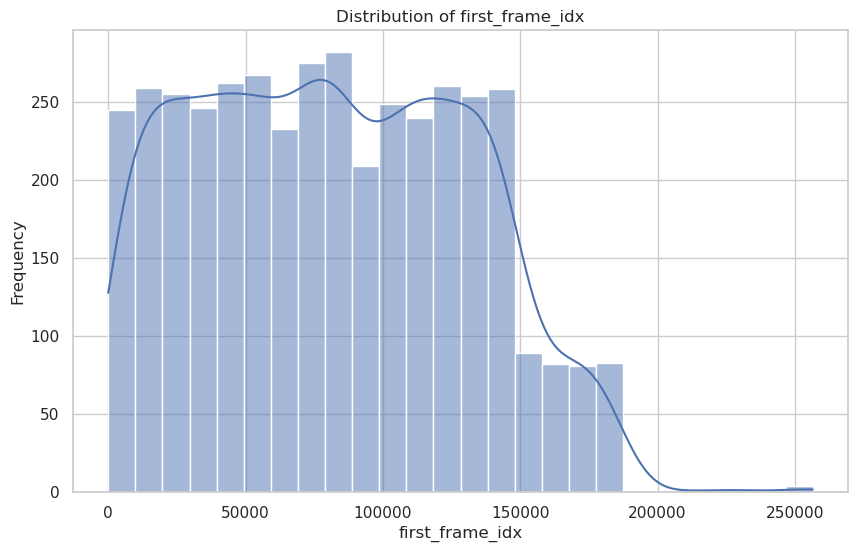

Categorical columns found: ['session', 'trial_id', 'condition_hash', 'image_size', 'modality', 'stim_type', 'tier']


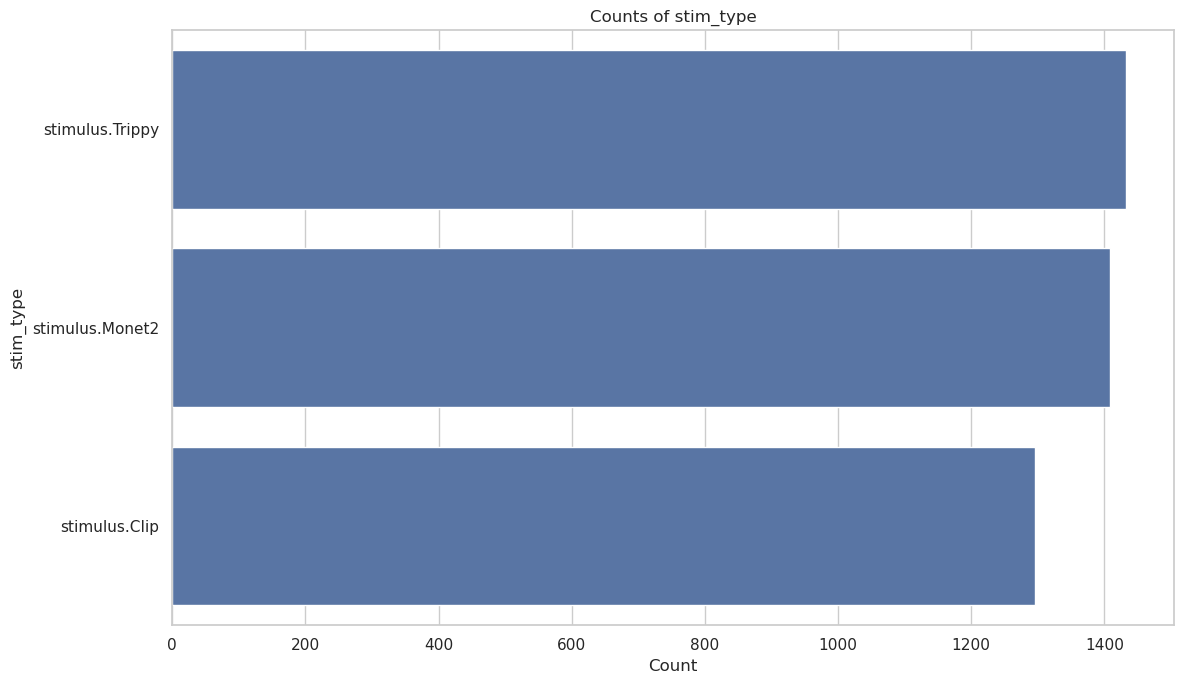

In [ ]:

if df is not None:
    # --- Example 1: Histogram of a numeric column ---
    numeric_cols = df.select_dtypes(include=np.number).columns
    if not numeric_cols.empty:
        numeric_column_to_plot = numeric_cols[0] # Choose the first numeric column
        plt.figure(figsize=(10, 6))
        sns.histplot(df[numeric_column_to_plot], kde=True)
        plt.title(f'Distribution of {numeric_column_to_plot}')
        plt.xlabel(numeric_column_to_plot)
        plt.ylabel('Frequency')
        plt.show()
    else:
        print("No numeric columns found for histogram.")

    # --- Example 2: Count plot of a categorical column ---
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    print(f"Categorical columns found: {categorical_cols.tolist()}")
    # Select a categorical column with a reasonable number of unique values
    categorical_column_to_plot = 'stim_type'
            
    if categorical_column_to_plot:
        plt.figure(figsize=(12, 7))
        sns.countplot(y=df[categorical_column_to_plot], order = df[categorical_column_to_plot].value_counts().index)
        plt.title(f'Counts of {categorical_column_to_plot}')
        plt.xlabel('Count')
        plt.ylabel(categorical_column_to_plot)
        plt.tight_layout()
        plt.show()
    else:
        print("No suitable categorical columns found for count plot.")
else:
    print("\nDataFrame not available for plotting.")

In [40]:
df_A["num_frames"].sum(), df_B["num_frames"].sum()

(1241400, 2946596)

In [41]:
set(df_A["num_frames"]), set(df_B["num_frames"])

({300}, {298, 300, 900})

In [48]:
set(df_B[df_B["stim_type"] == "stimulus.Clip"]["num_frames"])

{298, 300}

In [56]:
len(set(df_B.session)), len(set(df_A.session)), len(set(df_B.session).intersection(set(df_A.session)))

(47, 66, 47)

In [59]:
# Quantify the number of hashes in each session of df_A and df_B
from collections import Counter

hashes_A = Counter(df_A["session"])
hashes_B = Counter(df_B["session"])
print("Hashes in df_A sessions:", hashes_A)
print("Hashes in df_B sessions:", hashes_B)

# Compare the hashes between df_A and df_B
common_hashes = set(hashes_A.keys()).intersection(set(hashes_B.keys()))
print("Common hashes between df_A and df_B:", len(common_hashes))

Hashes in df_A sessions: Counter({'dynamic22084-2-11-Video-512cdd91f251cf74fff81375926f4002_30hz': 120, 'dynamic22279-5-15-Video-512cdd91f251cf74fff81375926f4002_30hz': 120, 'dynamic22285-2-10-Video-512cdd91f251cf74fff81375926f4002_30hz': 120, 'dynamic17797-4-7-Video-021a75e56847d574b9acbcc06c675055_30hz': 60, 'dynamic17797-5-7-Video-021a75e56847d574b9acbcc06c675055_30hz': 60, 'dynamic17797-6-2-Video-021a75e56847d574b9acbcc06c675055_30hz': 60, 'dynamic21608-2-18-Video-512cdd91f251cf74fff81375926f4002_30hz': 60, 'dynamic17797-6-4-Video-021a75e56847d574b9acbcc06c675055_30hz': 60, 'dynamic17797-6-6-Video-021a75e56847d574b9acbcc06c675055_30hz': 60, 'dynamic17797-6-7-Video-021a75e56847d574b9acbcc06c675055_30hz': 60, 'dynamic17797-7-3-Video-021a75e56847d574b9acbcc06c675055_30hz': 60, 'dynamic17797-9-3-Video-021a75e56847d574b9acbcc06c675055_30hz': 60, 'dynamic17797-9-6-Video-021a75e56847d574b9acbcc06c675055_30hz': 60, 'dynamic17797-7-5-Video-021a75e56847d574b9acbcc06c675055_30hz': 60, 'dynami

In [65]:
len(data["metadata"]['optimal_subset_sessions'])

66